사진이 너무 많아서 저장공간이 부족하다..

군집이나 분류에 영향을 끼치지 않으면서 업로드된 사진의 용량을 줄일 수 있을까?

### 차원 축소
* 차원(dimension): 데이터가 가진 속성의 수. 앞의 과일의 경우 10,000개의 픽셀이 있으므로 10,000개의 차원을 가지는 것.
* 차원 축소(dimensionality reduction): 데이터를 가장 잘 나타내는 일부 특성을 선택해서 데이터 크기를 줄이고, 지도 학습 모델의 성능을 향상시키는 방법.

## 주성분 분석(PCA)

principal component analysis

데이터에 있는 분산이 큰 방향을 찾는다.

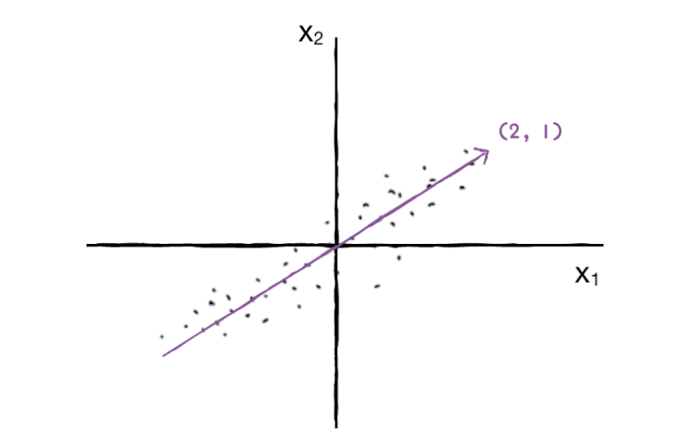

주성분(principal component): 원본 데이터에 있는 어떤 방향. 주성분 벡터의 원소 개수는 원본 데이터셋에 있는 특성 개수와 같다.

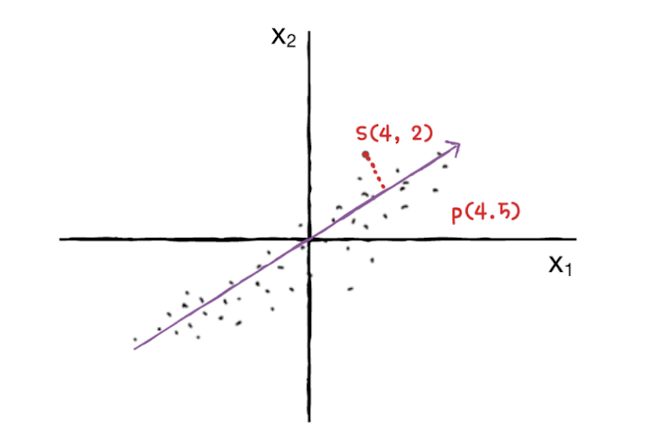

주성분을 사용해 차원을 줄일 수 있다. 위의 그림처럼 s(4, 2)를 주성분에 직각으로 투영하면 1차원 데이터를 만들 수 있다.

* 주성분은 원본 차원과 같고, 주성분으로 바꾼 데이터는 차원이 줄어든다.
* 주성분은 분산이 가장 큰 방향이므로, 주성분에 투영하여 바꾼 데이터는 원본이 가지고 있는 특성을 가장 잘 나타내고 있을 것이다.

첫 번째 주성분을 찾은 다음, 이 벡터에 수직이고 분산이 가장 큰 다음 방향을 찾는다. 그 벡터가 두 번째 주성분이 된다.

In [1]:
# 과일 데이터 다운로드, 넘파이 배열로 적재
!wget -O fruits_300.npy https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy

import numpy as np 
fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100*100)

--2026-03-14 03:45:51--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3000128 (2.9M) [application/octet-stream]
Saving to: ‘fruits_300.npy’

fruits_300.npy      100%[===================>]   2.86M  --.-KB/s    in 0.07s   

2026-03-14 03:45:51 (39.2 MB/s) - ‘fruits_300.npy’ saved [3000128/3000128]



In [2]:
# n_components 매개변수에 주성분의 개수를 지정
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
pca.fit(fruits_2d)

PCA(n_components=50)

In [3]:
# 배열의 크기 확인
print(pca.components_.shape)

(50, 10000)


50개의 주성분, 10,000개의 특성 개수(원본 데이터와 같다)

In [5]:
# 각 클러스터가 어떤 이미지 나타내는지 그림으로 출력
import matplotlib.pyplot as plt
def draw_fruits(arr, ratio=1):
    n = len(arr)    # n은 샘플 개수
    rows = int(np.ceil(n/10))   # 샘플 개수를 10으로 나눠서 전체 행 개수 계산
    cols = n if rows <2 else 10   # 행이 1개면 열의 개수는 샘플의 개수. 아니면 10개

    fig, axs = plt.subplots(rows, cols,
                            figsize=(cols*ratio, rows*ratio), squeeze=False)
    
    for i in range(rows):
        for j in range(cols):
            if i*10 + j < n:    # n개까지만 그린다.
                axs[i, j].imshow(arr[i*10 + j], cmap='gray_r')
            axs[i, j].axis('off')
    plt.show()

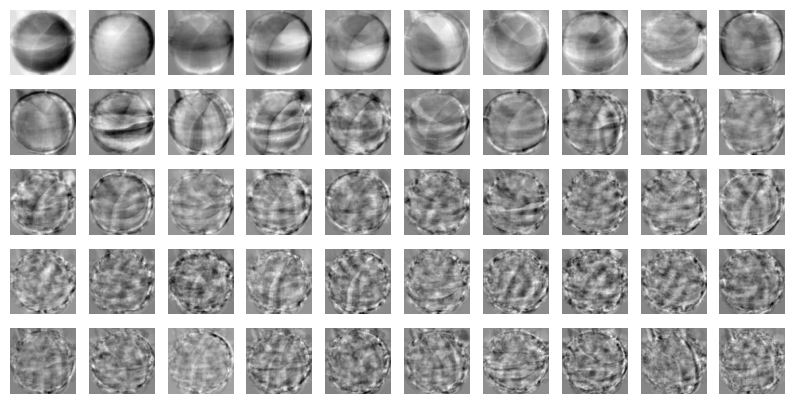

In [6]:
# 주성분을 그림으로 그리기
draw_fruits(pca.components_.reshape(-1, 100, 100))

원본 데이터에서 가장 분산이 큰 방향을 순서대로 나타낸 것. (데이터셋에 있는 특징을 잡아냈다고도 볼 수 있다.)

In [7]:
print(fruits_2d.shape)

(300, 10000)


원래는 10,000개의 픽셀(특성)을 가진 300개의 이미지

50개의 주성분을 찾은 PCA 모델을 사용해서 (300, 50) 크기의 배열로 변환한다.

즉 fruits_pca 배열은 50개의 특성을 가진 데이터로 축소된다.

In [8]:
# PCA로 원본 데이터의 차원 50으로 줄이기
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 50)


데이터의 차원을 줄였다. 그렇다면 다시 원상 복구할 수 있을까?

### 원본 데이터 재구성

10,000개의 특성을 50개로 줄여서 어느 정도 손실이 있지만, 최대한 분산이 큰 방향으로 데이터를 투영했기 때문에 원본 데이터를 상당 부분 재구성할 수 있다.

In [9]:
# inverse_transform() 메서드로 10,000개의 특성 복원하기
fruits_inverse = pca.inverse_transform(fruits_pca)
print(fruits_inverse.shape)

(300, 10000)


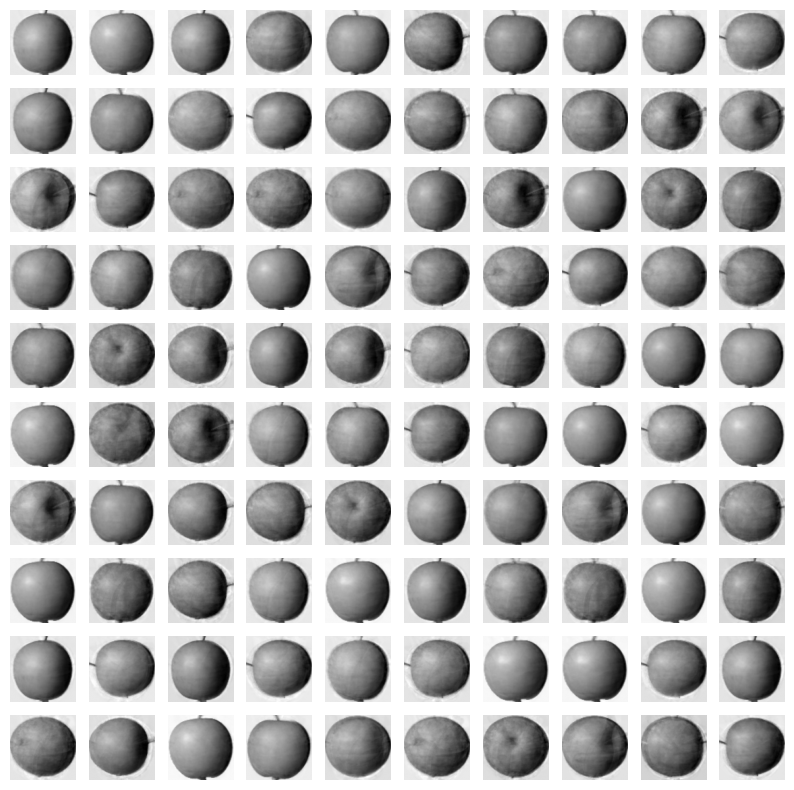

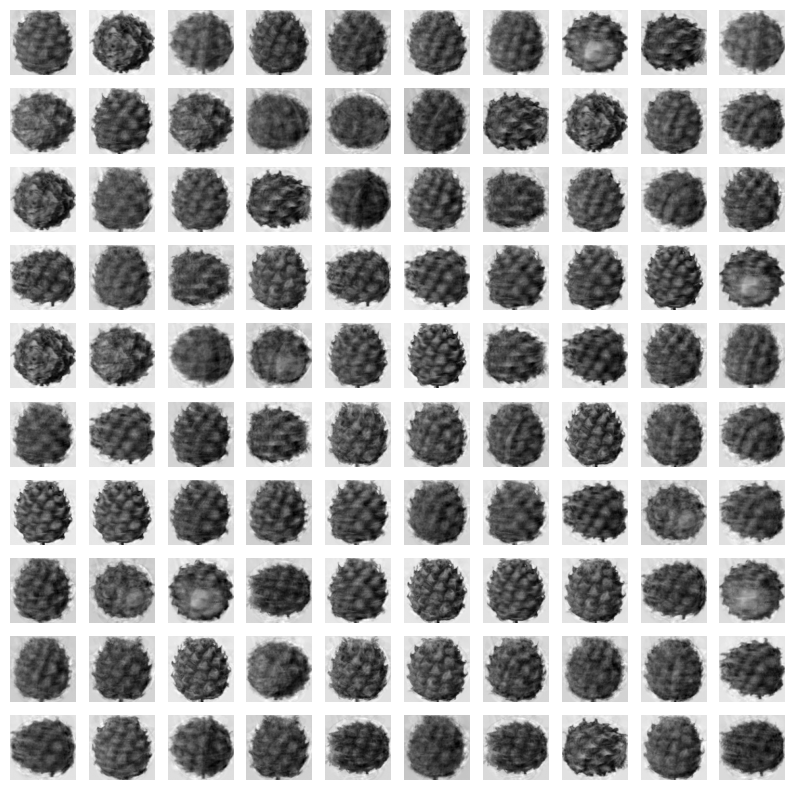

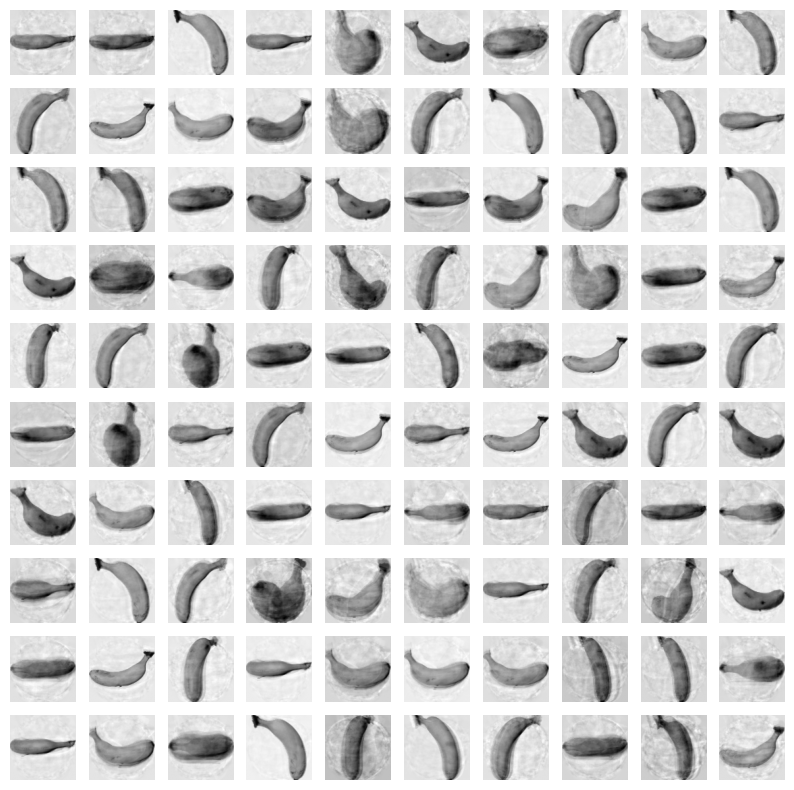

In [11]:
# 복원한 데이터 100개씩 나누어 출력
fruits_reconstruct = fruits_inverse.reshape(-1, 100, 100)
for start in [0, 100, 200]:
    draw_fruits(fruits_reconstruct[start:start+100])

일부 흐리고 번진 부분이 있지만 거의 모든 과일이 잘 복원되었다! 50개의 특성이 분산을 가장 잘 보존하도록 변환되었기 때문이다.

### 설명된 분산 (explained variance)
주성분이 원본 데이터의 분산을 얼마나 잘 나타내는지 기록한 값.

explained_variance_ratio_에 각 주성분의 설명된 분산 비율 기록되어 있다.

In [12]:
# 50개 주성분으로 표현하고 있는 총 분산 비율 구하기
print(np.sum(pca.explained_variance_ratio_))

0.9215031728169595


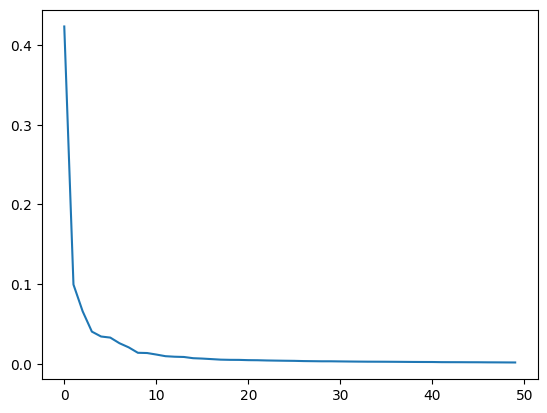

In [13]:
# 설명된 분산의 비율 그래프로 그리기
plt.plot(pca.explained_variance_ratio_)
plt.show()

처음 10개의 주성분이 대부분의 분산을 표현하고 있다.

### 다른 알고리즘과 함께 사용하기

PCA로 차원 축소된 데이터 사용하여 지도 학습 모델 훈련하기

In [14]:
# 로지스틱 회귀 모델 만들기
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [15]:
# 타깃값으로 사과 0, 파인애플 1, 바나나 2로 지정
target = np.array([0]*100 + [1]*100 + [2]*100)

In [ ]:
# 원본 데이터 사용, 교차검증으로 로지스틱 회귀 모델 성능 파악
from sklearn.model_selection import cross_validate
scores = cross_validate(lr, fruits_2d, target)

print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))  # 각 교차 검증 폴드의 훈련 시간

0.9966666666666667
0.8966995716094971


In [17]:
# PCA로 축소한 데이터와 비교
scores = cross_validate(lr, fruits_pca, target)

print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.014939165115356446


훈련 시간이 0.01초로 앞의 과정에 비해 매우 감소했다.

PCA로 훈련 데이터의 차원을 축소하면 저장 공간뿐만 아니라 머신러닝 모델의 훈련 속도도 높일 수 있다.

In [18]:
# 매개변수에 주성분의 개수 지정하는 대신, 원하는 설명된 분산의 비율을 입력할 수도 있다.
# 설명된 분산의 50%에 달하는 주성분을 찾도록 PCA 모델 만들기
pca = PCA(n_components=0.5)
pca.fit(fruits_2d)

PCA(n_components=0.5)

In [19]:
# 몇 개의 주성분 찾았는지 확인
print(pca.n_components_)

2


단 2개의 특성만으로 원본 데이터에 있는 분산의 50%를 표현할 수 있다.

In [20]:
# 위의 모델로 원본 데이터 변환 
# 주성분 2개이므로 변환된 데이터의 크기는 (300, 2)
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 2)


In [21]:
# 2개의 특성만으로도 교차 검증의 결과 좋은지 확인
scores = cross_validate(lr, fruits_pca, target)

print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

0.99
0.0962916374206543


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


2개의 특성만 사용했음에도 99%의 정확도 달성!

In [22]:
# 차원 축소된 데이터를 이용해 k-평균 알고리즘으로 클러스터 찾기
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_pca)
print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([110,  99,  91]))


3개의 클러스터가 각각 110개, 99개, 91개의 샘플을 포함한다.

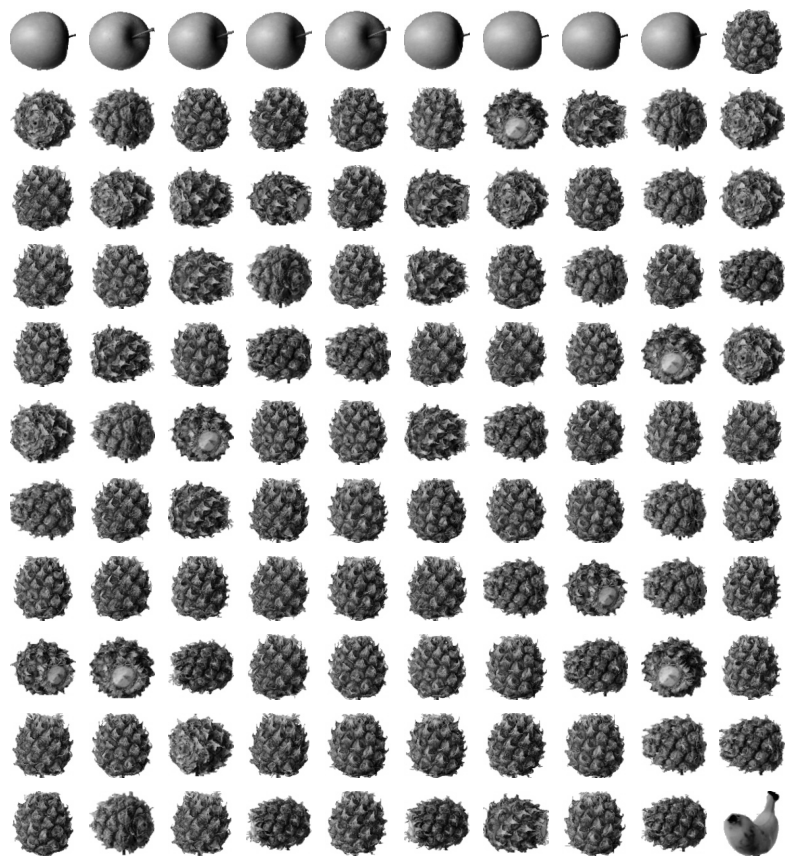

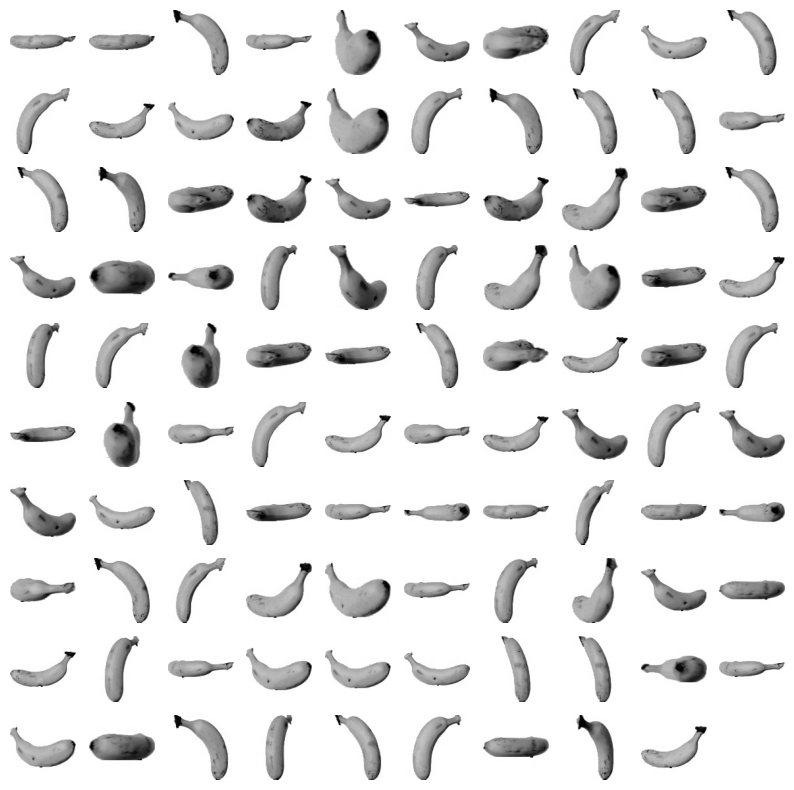

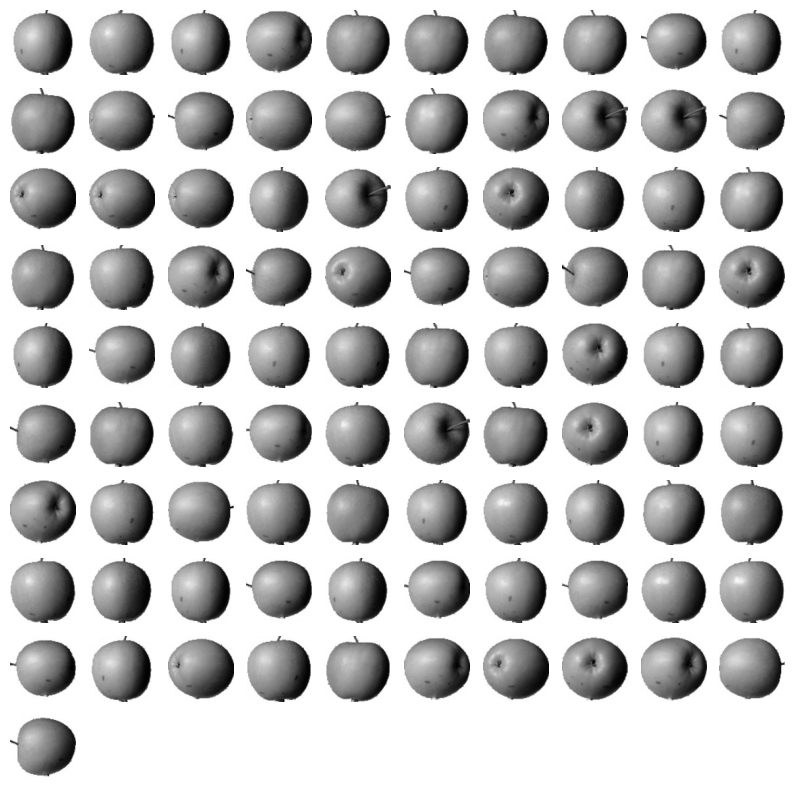

In [23]:
# KMeans로 찾은 레이블을 사용해 과일 이미지 출력
for label in range(0, 3):
    draw_fruits(fruits[km.labels_==label])

일부 잘못 분류된 과일이 있긴 하다.

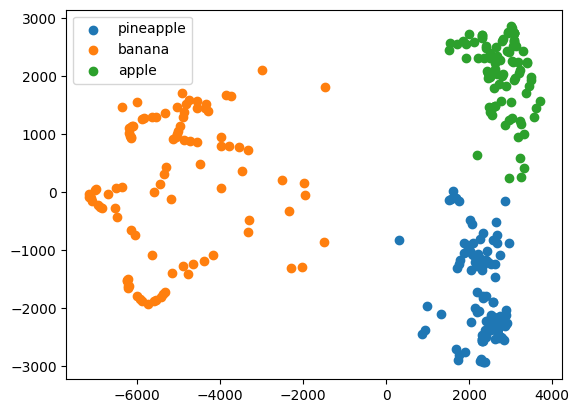

In [24]:
# 3개 이하로 차원을 줄였기 때문에 화면에 출력하기 쉽다.
# 클러스터별로 나누어 산점도 그리기
for label in range(0, 3):
    data = fruits_pca[km.labels_ == label]
    plt.scatter(data[:, 0], data[:, 1])
plt.legend(['pineapple', 'banana', 'apple'])
plt.show()

사과와 파인애플 클러스터의 경계가 가깝다. 

두 클러스터의 샘플은 몇 개가 혼동을 일으키기 쉬울 것으로 추정된다.